In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [5]:
# Đọc dữ liệu đã chuẩn hóa
df = pd.read_csv("milk_standard_scaler.csv")

print("Kích thước dữ liệu:", df.shape)
display(df.head())

Kích thước dữ liệu: (1059, 8)


,pH,Temprature,Taste,Odor,Fat,Turbidity,Colour,Grade
0,-0.021531,-0.914107,0.910503,-0.872962,0.699608,-0.982217,0.501600,2
1,-0.021531,-0.815035,-1.098294,1.145525,-1.429372,1.018105,0.269333,2
2,1.336564,2.553438,0.910503,1.145525,0.699608,1.018105,-1.356536,0
3,2.051351,-1.013180,0.910503,1.145525,-1.429372,1.018105,0.733867,0
4,-0.021531,-0.715962,-1.098294,-0.872962,-1.429372,-0.982217,0.733867,1


In [6]:
# Tách dữ liệu
X = df.drop("Grade", axis=1)
y = df["Grade"]

In [7]:
# Chia tập train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (847, 7)
Test : (212, 7)


In [8]:
# Tìm tham số tốt nhất
param_grid = {
    "var_smoothing": np.logspace(-12, -1, 50)
}

grid = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameter:")
print(grid.best_params_)
print()

# Dự đoán
y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred, average="weighted"))
print()
print(classification_report(y_test, y_pred))

Best parameter:
{'var_smoothing': np.float64(0.004498432668969453)}

Accuracy : 0.9622641509433962
F1-score : 0.9626181030366769

              precision    recall  f1-score   support

           0       1.00      0.94      0.97        86
           1       0.97      0.96      0.97        75
           2       0.89      1.00      0.94        51

    accuracy                           0.96       212
   macro avg       0.96      0.97      0.96       212
weighted avg       0.97      0.96      0.96       212



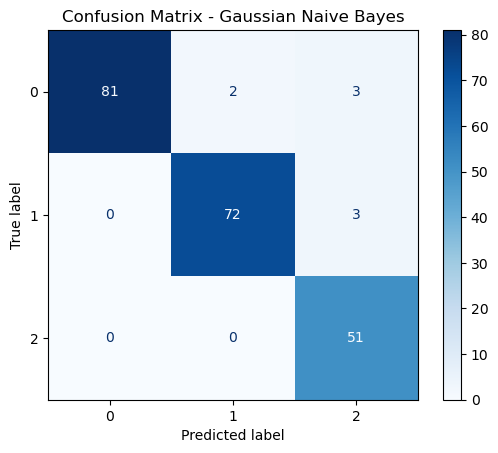

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=best_model.classes_
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Gaussian Naive Bayes")
plt.show()

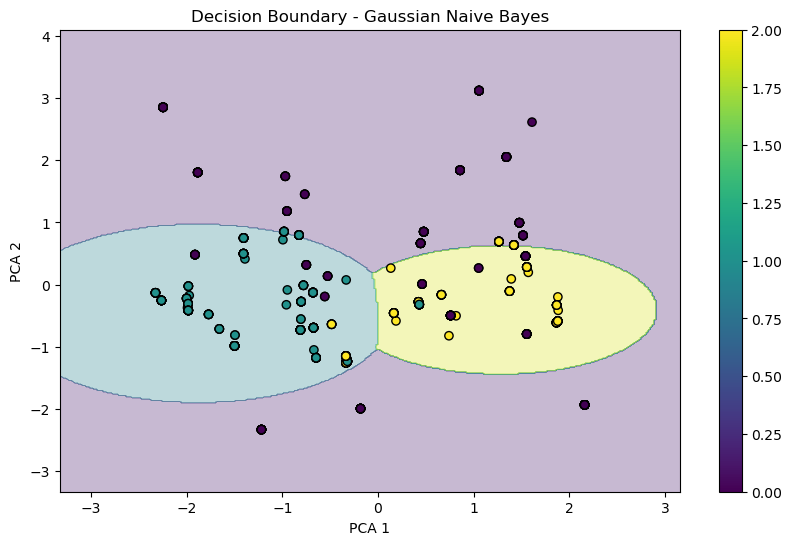

In [10]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

# PCA xuống 2 chiều
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train lại trên dữ liệu PCA
gnb = GaussianNB(
    var_smoothing=grid.best_params_["var_smoothing"]
)

gnb.fit(X_train_pca, y_train)

# Tạo lưới
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = gnb.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

scatter = plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    edgecolor='k'
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Decision Boundary - Gaussian Naive Bayes")
plt.colorbar(scatter)
plt.show()

In [11]:
print("Best var_smoothing:",
      grid.best_params_["var_smoothing"])

print("Class Prior:")
print(best_model.class_prior_)

print("Classes:")
print(best_model.classes_)

Best var_smoothing: 0.004498432668969453
Class Prior:
[0.40495868 0.35301063 0.2420307 ]
Classes:
[0 1 2]
